In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('../../data/processed/final_EDA_df.csv')

In [3]:
df.columns

Index(['고객ID', '패션뉴스구독여부', '멤버십상태', '뉴스레터수신빈도', '연령', '구매일', '가격', '상품그룹',
       '연령대', '거래날짜', '이전구매일', '구매간격(일)', 'API ratio', '전체고객이탈여부', '신규고객이탈'],
      dtype='str')

In [4]:
import pandas as pd

# 1. 먼저 '거래날짜' 컬럼을 날짜 형식으로 변환 (가장 중요!)
df['거래날짜'] = pd.to_datetime(df['거래날짜'])

# 2. 날짜 형식인 상태에서 가장 최근 날짜(Maximum) 확인
max_date = df['거래날짜'].max()

# 3. 이제 날짜 객체이므로 1년 전 날짜 계산이 가능합니다.
start_date = max_date - pd.DateOffset(years=1)

# 4. 1년치 데이터만 필터링
filtered_df = df[df['거래날짜'] >= start_date].reset_index(drop=True)

print(f"최근 날짜: {max_date}")
print(f"시작 날짜 (1년 전): {start_date}")
# print(filtered_df)
filtered_df = filtered_df.drop(['API ratio'],axis=1)
filtered_df.info()

# filtered_df.to_csv('C:/Users/Playdata/Downloads/one_year_churn.csv')


최근 날짜: 2020-09-22 00:00:00
시작 날짜 (1년 전): 2019-09-22 00:00:00
<class 'pandas.DataFrame'>
RangeIndex: 14905795 entries, 0 to 14905794
Data columns (total 14 columns):
 #   Column    Dtype         
---  ------    -----         
 0   고객ID      str           
 1   패션뉴스구독여부  float64       
 2   멤버십상태     str           
 3   뉴스레터수신빈도  str           
 4   연령        float64       
 5   구매일       str           
 6   가격        float64       
 7   상품그룹      str           
 8   연령대       str           
 9   거래날짜      datetime64[us]
 10  이전구매일     str           
 11  구매간격(일)   float64       
 12  전체고객이탈여부  int64         
 13  신규고객이탈    int64         
dtypes: datetime64[us](1), float64(4), int64(2), str(7)
memory usage: 1.6 GB


In [5]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

cat_cols = ['상품그룹', '멤버십상태', '연령대']
le_dict = {}

# 1. filtered_df가 안전하게 복사본인지 확인 (중요!)
filtered_df = filtered_df.copy()

for col in cat_cols:
    le = LabelEncoder()
    # 1. 정수로 변환된 결과물을 변수에 담기
    encoded_values = le.fit_transform(filtered_df[col].astype(str))

#컬럼 타입을 object로 변경 (숫자를 수용할 수 있게 함)
    filtered_df[col] = filtered_df[col].astype(object)

#데이터 대입
    filtered_df.loc[:, col] = encoded_values
    le_dict[col] = le

# 3. 결과 확인
print(filtered_df[cat_cols].head())
print(filtered_df[cat_cols].dtypes)

  상품그룹 멤버십상태 연령대
0    7     0   4
1    7     0   4
2    7     0   4
3    0     0   4
4    7     0   4
상품그룹     object
멤버십상태    object
연령대      object
dtype: object


In [6]:
mapping_result = {}

for col, le in le_dict.items():
    # 클래스(문자)와 인덱스(숫자)를 매칭하여 딕셔너리 생성
    mapping_result[col] = dict(zip(le.classes_, range(len(le.classes_))))

# 출력해서 확인
import pprint
pprint.pprint(mapping_result)

{'멤버십상태': {'ACTIVE': 0, 'LEFT CLUB': 1, 'PRE-CREATE': 2},
 '상품그룹': {'Accessories': 0,
          'Bags': 1,
          'Cosmetic': 2,
          'Fun': 3,
          'Furniture': 4,
          'Garment Full body': 5,
          'Garment Lower body': 6,
          'Garment Upper body': 7,
          'Garment and Shoe care': 8,
          'Interior textile': 9,
          'Items': 10,
          'Nightwear': 11,
          'Shoes': 12,
          'Socks & Tights': 13,
          'Stationery': 14,
          'Swimwear': 15,
          'Underwear': 16,
          'Underwear/nightwear': 17,
          'Unknown': 18},
 '연령대': {'0': 0,
         '10대': 1,
         '20대': 2,
         '30대': 3,
         '40대': 4,
         '50대': 5,
         '60대': 6,
         '70대 이상': 7}}


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier

# 1. 범주형 컬럼 리스트 (가격은 제외)
cat_cols = ['상품그룹', '멤버십상태', '연령대']

# ---------------------------
# 1️⃣ 신규 고객 모델 (LightGBM)
# ---------------------------
X_new = filtered_df[['상품그룹', '멤버십상태', '연령대', '가격']].copy()
y_new = filtered_df['신규고객이탈']

# 범주형 컬럼만 타입 변경 (가격은 수치형 그대로 유지)
for col in cat_cols:
    X_new[col] = X_new[col].astype('category')

# 데이터 분할
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(
    X_new, y_new, test_size=0.2, stratify=y_new, random_state=42
)

model_new = LGBMClassifier(
    objective='binary',
    metric='auc',
    is_unbalance=True, # 신규 고객 이탈자 수가 적을 경우 유용
    n_jobs=-1,
    random_state=42
)

# 학습: categorical_feature 명시
model_new.fit(Xn_tr, yn_tr, categorical_feature=cat_cols)

preds_new = model_new.predict_proba(Xn_te)[:, 1]
print(f"신규 고객 모델 AUC: {roc_auc_score(yn_te, preds_new):.4f}")


# ---------------------------
# 2️⃣ 전체 고객 모델 (LightGBM)
# ---------------------------
X_total = filtered_df[['상품그룹', '멤버십상태', '연령대', '가격']].copy()
y_total = filtered_df['전체고객이탈여부']

# 동일하게 범주형 컬럼만 타입 변경
for col in cat_cols:
    X_total[col] = X_total[col].astype('category')

# 데이터 분할
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_total, y_total, test_size=0.2, stratify=y_total, random_state=42
)

model_total = LGBMClassifier(
    objective='binary',
    metric='auc',
    is_unbalance=True,
    n_jobs=-1,
    random_state=42
)

# 학습: 전체 고객 모델도 동일하게 카테고리 반영
model_total.fit(Xt_tr, yt_tr, categorical_feature=cat_cols)

preds_total = model_total.predict_proba(Xt_te)[:, 1]
print(f"전체 고객 모델 AUC: {roc_auc_score(yt_te, preds_total):.4f}")

[LightGBM] [Info] Number of positive: 558382, number of negative: 11366254
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.050817 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 277
[LightGBM] [Info] Number of data points in the train set: 11924636, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.046826 -> initscore=-3.013361
[LightGBM] [Info] Start training from score -3.013361
신규 고객 모델 AUC: 0.7138
[LightGBM] [Info] Number of positive: 5416286, number of negative: 6508350
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.059793 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 279
[LightGBM] [Info] Number of data points in the train set: 11924636, number of used

In [8]:
# 혼동 행렬, 정밀도, 재현율
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
y_pred = model_total.predict(Xt_te)
print('혼동행렬(Confusion Matrix) \n',confusion_matrix(y_pred=y_pred, y_true=yt_te),'\n')
print('\n',f'정밀도 : {precision_score(yt_te,y_pred)}')
print('\n',f'재현율 : {recall_score(yt_te,y_pred)}')
print('\n',f'정확도 : {accuracy_score(yt_te,y_pred)}')


혼동행렬(Confusion Matrix) 
 [[1091861  535226]
 [ 823394  530678]] 


 정밀도 : 0.49786659961872737

 재현율 : 0.3919126900194377

 정확도 : 0.544264495788383


In [9]:
# classfication_report 
from sklearn.metrics import classification_report

print(classification_report(yt_te,y_pred))

              precision    recall  f1-score   support

           0       0.57      0.67      0.62   1627087
           1       0.50      0.39      0.44   1354072

    accuracy                           0.54   2981159
   macro avg       0.53      0.53      0.53   2981159
weighted avg       0.54      0.54      0.54   2981159



#### 그래프

In [10]:
from sklearn.preprocessing import Binarizer
from sklearn.metrics import accuracy_score

def evaluate_binary_clf(yt_te,y_pred):
    print('혼동행렬')
    print(confusion_matrix(yt_te,y_pred),'\n')
    print(f'정확도 : {accuracy_score(yt_te,y_pred):.4f}/정밀도{precision_score(yt_te,y_pred)}/재현율{recall_score(yt_te,y_pred)}')

pred_proba = model_total.predict_proba(Xt_te)
    

혼동행렬
[[      0 1627087]
 [      0 1354072]] 

정확도 : 0.4542/정밀도0.45420992305341645/재현율1.0
혼동행렬
[[      0 1627087]
 [      0 1354072]] 

정확도 : 0.4542/정밀도0.45420992305341645/재현율1.0
혼동행렬
[[   1010 1626077]
 [    240 1353832]] 

정확도 : 0.4545/정밀도0.4543199137960253/재현율0.9998227568401089
혼동행렬
[[1091861  535226]
 [ 823394  530678]] 

정확도 : 0.5443/정밀도0.49786659961872737/재현율0.3919126900194377
혼동행렬
[[1585283   41804]
 [1289477   64595]] 

정확도 : 0.5534/정밀도0.6071015705034821/재현율0.047704257971511115
혼동행렬
[[1627085       2]
 [1354008      64]] 

정확도 : 0.5458/정밀도0.9696969696969697/재현율4.7264842637614544e-05


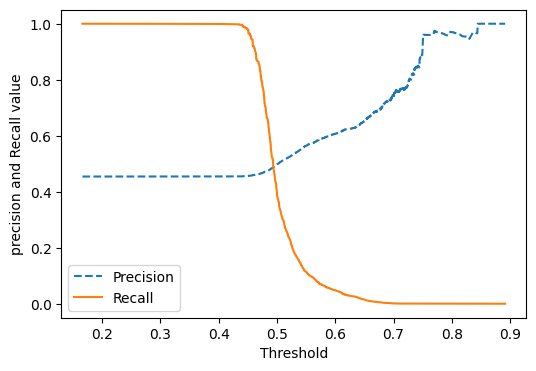

In [11]:

from sklearn.preprocessing import Binarizer
from sklearn.metrics import accuracy_score
pred_proba = model_total.predict_proba(Xt_te)
pred_proba_1 = pred_proba[:,1].reshape(-1,1)

thresholds = [0.0, 0.1,0.3,0.5,0.6,0.8]

for threshold in thresholds:
    binarizer = Binarizer(threshold=threshold)
    custom_pred = binarizer.fit_transform(pred_proba_1)
    evaluate_binary_clf(yt_te, custom_pred)

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(yt_te, pred_proba_1) # 정밀도, 재현율은 마지막에 극단적으로 낮은 임계치 값을 적용한 값을 보여줌 ([:-1]) 1개 뺴주기

plt.figure(figsize=(6,4))
plt.plot(thresholds, precisions[:-1], linestyle='--', label='Precision')
plt.plot(thresholds, recalls[:-1], label = 'Recall')
plt.xlabel('Threshold')
plt.ylabel('precision and Recall value')
plt.legend()
plt.show()

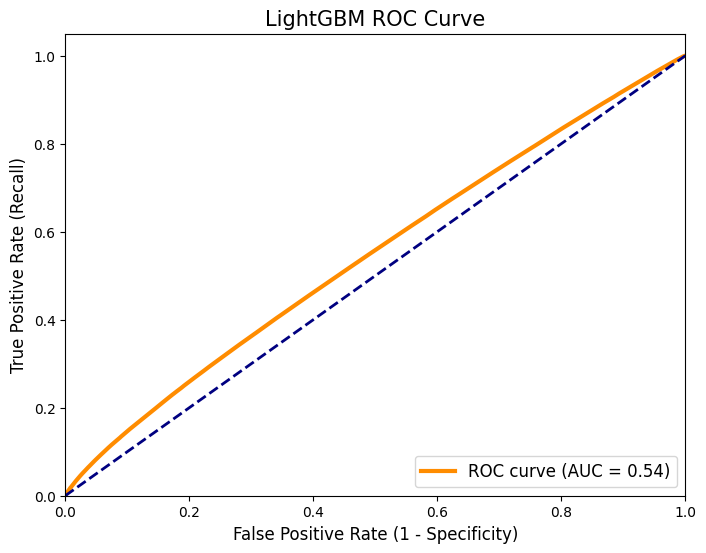

0.5448913790673355

In [12]:
from sklearn.metrics import roc_curve, roc_auc_score


pred_proba = model_total.predict_proba(Xt_te)
pred_proba_1 = pred_proba[:,1].reshape(-1,1)


# fpr, tpr, thresholds = roc_curve(y_test, y_pred)

from sklearn.metrics import auc
fpr, tpr, thresholds = roc_curve(yt_te, pred_proba_1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC 곡선 그리기 (굵기 조절 및 색상 강조)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 대각선 점선 (Random Guess 기준선)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('LightGBM ROC Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

# plt.savefig('./graphs/RF_balanced_ROC_curve.png', dpi=300, bbox_inches='tight')

plt.show()

# roc_auc_score(y_test, pred_proba[:, 1])
roc_auc_score(yt_te, pred_proba_1)


  feature  importance
3      가격        1837
0    상품그룹         681
2     연령대         390
1   멤버십상태          92


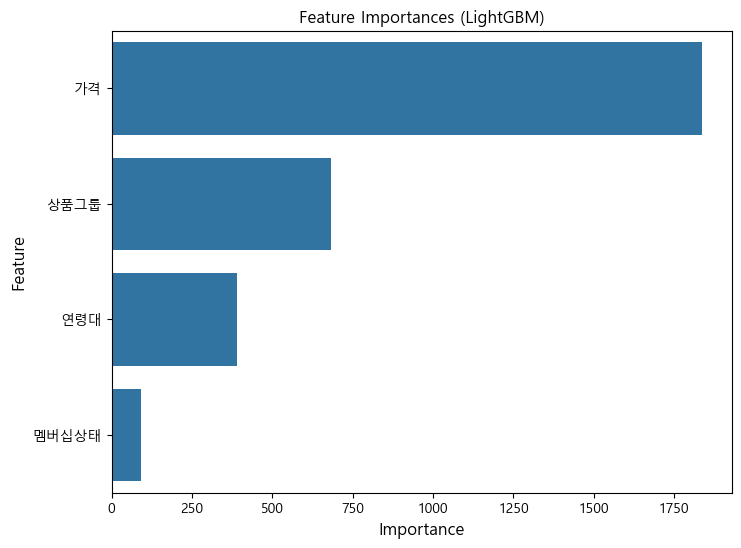

In [13]:
# ==============================
# Feature Importance
# ==============================
importances = model_total.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X_new.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df.head(10))

import seaborn as sns
# 한글 설정 (윈도우)
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 기본 한글 폰트

plt.figure(figsize=(8,6))
sns.barplot(
    data=feature_importance_df.head(15),
    x='importance',
    y='feature'
)
plt.title('Feature Importances (LightGBM)')
plt.xlabel('Importance',fontsize=12)
plt.ylabel('Feature',fontsize=12)
plt.show()

---

- XGBoost

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import xgboost as xgb

# 1. 범주형 컬럼 리스트 (가격은 제외)
cat_cols = ['상품그룹', '멤버십상태', '연령대']

# def train_xgb_model(X,y, name="MODEL"):
#     # 데이터 분할
#     # X_tr은 훈련 데이터의 특징(독립 변수), 
#     # X_te는 테스트 데이터의 특징, 
#     # y_tr은 훈련 데이터의 타겟(종속 변수), 
#     # y_te는 테스트 데이터의 타겟
#     X_tr, X_te, y_tr, y_te = train_test_split(
#         X, y,test_size = 0.2, stratify=y, random_state=42
#     )

#     # 이 코드들은 XGBoost에서 클래스 불균형을 처리하기 위한 방법.
#     # pos와 neg는 각각 양성 클래스(1)와 음성 클래스(0)의 샘플 수를 계산하는 부분.
#     pos = (y_tr ==1).sum()
#     neg = (y_tr ==0).sum()
#     # spw는 양성 클래스에 대한 가중치로, 양성 클래스가 적을수록 더 높은 가중치를 부여하여 
#     # 모델이 양성 클래스를 더 잘 학습하도록 유도하는 역할을 함
#     #  pos가 0보다 큰 경우에만 계산하며, 
#     # 그렇지 않으면 spw를 1.0으로 설정하여 가중치를 적용하지 않음.
#     spw =(neg/pos) if pos > 0 else 1.0


#     model = XGBClassifier(
#         objective="binary:logistic",   # 이진 분류 문제에 적합한 목적 함수
#         eval_metric="auc",          # AUC를 평가 지표로 사용
#         tree_method="hist",          # 범주형 지원/속도에 유리
#         enable_categorical=True,     #category dtype 처리
#         n_estimators=2000,           # 충분히 큰 트리 수
#         learning_rate=0.05,
#         max_depth=6,
#         subsample=0.8,
#         colsample_bytree=0.8,       # 과적합 방지
#         scale_pos_weight=spw,        # 불균형 보정
#         n_jobs=-1,                  # 병렬 처리 활용
#         random_state=42,
#         early_stopping_rounds=50,  # 조기 종료 설정
#     )


#     model.fit(
#         X_tr, y_tr, 
#         eval_set=[(X_te, y_te)],    # eval_set은 모델이 학습하는 동안 검증 데이터로 사용되는 데이터셋을 지정하는 매개변수
#         # X_te와 y_te는 각각 검증 데이터의 특징과 타겟을 나타냄
#         verbose=False           # verbose는 학습 과정에서 출력되는 로그의 양을 제어하는 매개변수로, 
#                                 # False로 설정하면 학습 과정에서 로그가 출력되지 않음
#     )
    
#     # X_te는 테스트 데이터의 특징을 나타내며,
#     #  model.predict_proba(X_te)[:, 1]은 모델이 테스트 데이터에 대해 
#     # 양성 클래스(1)에 속할 확률을 예측하는 부분.
#     preds = model.predict_proba(X_te)[:, 1]
#     auc_score = roc_auc_score(y_te, preds)
#     print(f"{name} AUC: {auc_score:.4f}")


#     return model


def train_xgb_model_onehot(X, y, name="MODEL"):
    X = pd.get_dummies(X, columns=cat_cols)  

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    Xn_train, Xn_eval, yn_train, yn_eval = train_test_split(X_tr, y_tr, random_state=0)
    eval_set = [(Xn_train, yn_train), (Xn_eval, yn_eval)]


    pos = (y_tr == 1).sum()
    neg = (y_tr == 0).sum()
    spw = (neg / pos) if pos > 0 else 1.0

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=50
    )

    # 학습은 train, early stopping은 eval로 
    # verbose=False로 설정하여 학습 과정에서 로그가 출력되지 않도록 함
    model.fit(Xn_train, yn_train, eval_set=[(Xn_eval, yn_eval)], verbose=False)


    # 최종 평가
    proba = model.predict_proba(X_te)[:, 1]
    y_pred = (proba >= 0.5).astype(int)

    print(f"{name} AUC: {roc_auc_score(y_te, proba):.4f}")
    print(classification_report(y_te, y_pred))

    return model

# 신규 고객
X_new = filtered_df[['상품그룹', '멤버십상태', '연령대', '가격']].copy()
y_new = filtered_df['신규고객이탈']

model_new = train_xgb_model_onehot(X_new, y_new, name="신규 고객 XGBoost(OneHot)")

# 전체 고객
X_total = filtered_df[['상품그룹', '멤버십상태', '연령대', '가격']].copy()
y_total = filtered_df['전체고객이탈여부']

model_total = train_xgb_model_onehot(X_total, y_total, name="전체 고객 XGBoost(OneHot)")



신규 고객 XGBoost(OneHot) AUC: 0.7025
              precision    recall  f1-score   support

           0       0.97      0.77      0.86   2841563
           1       0.10      0.51      0.17    139596

    accuracy                           0.76   2981159
   macro avg       0.53      0.64      0.51   2981159
weighted avg       0.93      0.76      0.83   2981159

전체 고객 XGBoost(OneHot) AUC: 0.5436
              precision    recall  f1-score   support

           0       0.57      0.66      0.61   1627087
           1       0.50      0.40      0.44   1354072

    accuracy                           0.54   2981159
   macro avg       0.53      0.53      0.53   2981159
weighted avg       0.54      0.54      0.54   2981159



In [ ]:
# 전체 고객에 대한 모델평가(score)
X = pd.get_dummies(X_total, columns=cat_cols)
y = y_total
X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
model_new.score(X_tr, y_tr) #0.5471487767006054
model_new.score(X_te, y_te) # 0.5470801792188877



0.5471487767006054

In [26]:
# 신규 고객에 대한 모델평가(score)
X = pd.get_dummies(X_new, columns=cat_cols)
y = y_new
X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
model_new.score(X_tr, y_tr)



0.7623448631891154

In [27]:
model_new.score(X_te, y_te)

0.7621592810044684